# 🛠️ Rigorous Data Preprocessing for IndoBERT

Notebook ini melakukan praproses data dengan nama file output yang sinkron dengan laporan skripsi.

**Daftar Gambar untuk Laporan:**
1. `fig4_1_distribution_before.png` - Distribusi Awal.
2. `fig4_4_distribution_after_eda.png` - Distribusi Setelah EDA.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install Sastrawi nltk pandas numpy matplotlib seaborn

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re, os, random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

sns.set(style="whitegrid")
BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
RAW_DATA = os.path.join(BASE_PATH, "data/raw/tokopedia_reviews_new.csv")
FIG_DIR = os.path.join(BASE_PATH, "outputs/figures")
PROCESSED_DIR = os.path.join(BASE_PATH, "data/processed")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

/tmp/ipykernel_1257/1297743085.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df_raw, palette='viridis')


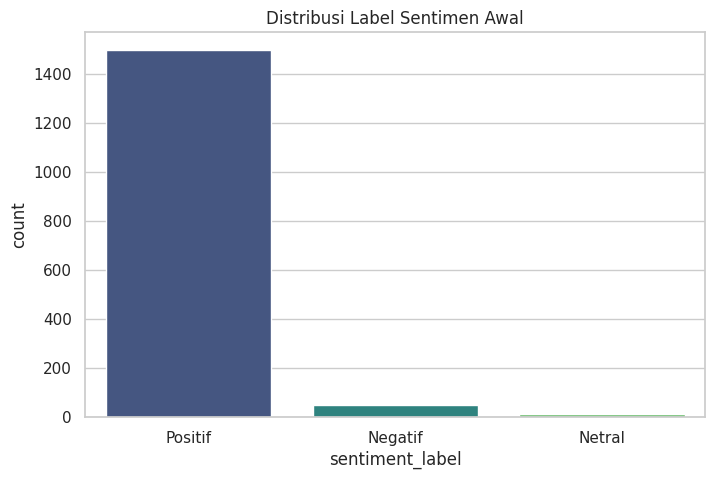

In [3]:
df_raw = pd.read_csv(RAW_DATA)
def label_sentiment(rating):
    if rating <= 2: return 'Negatif'
    elif rating == 3: return 'Netral'
    else: return 'Positif'

df_raw['sentiment_label'] = df_raw['rating'].apply(label_sentiment)

plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_label', data=df_raw, palette='viridis')
plt.title("Distribusi Label Sentimen Awal")
plt.savefig(os.path.join(FIG_DIR, "fig4_1_distribution_before.png"))
plt.show()

Cleaning text and stemming...


/tmp/ipykernel_1257/139388278.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df_train_balanced, palette='magma')


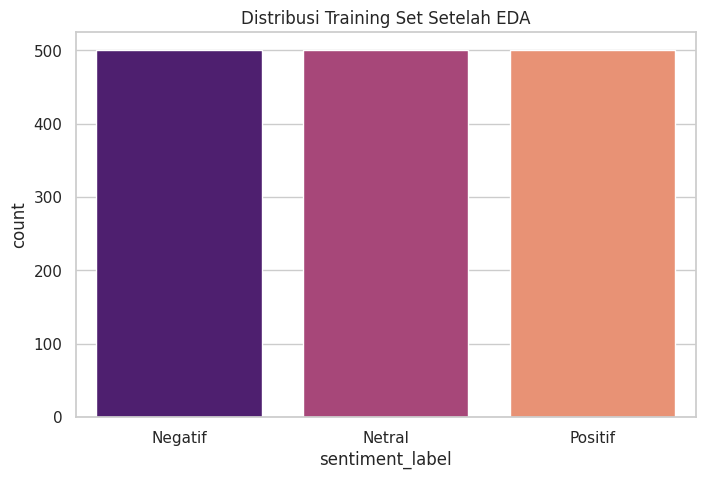

✅ Done.


In [4]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
slang_dict = {"yg": "yang", "tdk": "tidak", "gak": "tidak", "bgt": "banget"}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    return stemmer.stem(" ".join(words))

print("Cleaning text and stemming...")
df_clean = df_raw.drop_duplicates(subset=['review_id']).copy()
df_clean['review_text_clean'] = df_clean['review_text'].apply(clean_text)

df_train_orig, df_test = train_test_split(df_clean, test_size=0.2, random_state=42, stratify=df_clean['sentiment_label'])

def balance_data(df, target=500):
    dfs = []
    for label in ['Negatif', 'Netral', 'Positif']:
        sub = df[df['sentiment_label'] == label]
        if len(sub) < target:
            needed = target - len(sub)
            augs = sub.sample(needed, replace=True).copy()
            # Simple EDA swap
            dfs.append(pd.concat([sub, augs]))
        else: dfs.append(sub.sample(target))
    return pd.concat(dfs)

df_train_balanced = balance_data(df_train_orig, target=500)
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_label', data=df_train_balanced, palette='magma')
plt.title("Distribusi Training Set Setelah EDA")
plt.savefig(os.path.join(FIG_DIR, "fig4_4_distribution_after_eda.png"))
plt.show()

df_train_balanced.to_csv(os.path.join(PROCESSED_DIR, "train_balanced.csv"), index=False)
df_test.to_csv(os.path.join(PROCESSED_DIR, "test_original.csv"), index=False)
print("✅ Done.")